# Notebook 1: Machine Learning Baselines
## Project: Multi-Paradigm AI vs. Human Text Detection

### Objective
To establish a performance baseline using traditional Machine Learning architectures (Logistic Regression and Naive Bayes). Before moving to computationally expensive deep learning models, we must understand how well simple probabilistic and linear models perform.

### Methodology: TF-IDF Vectorization
Traditional ML models cannot read text; they require numerical features. We utilize the $\text{TF-IDF}$ (Term Frequency-Inverse Document Frequency) algorithm to convert texts into numerical vectors. 
* **The Limitation:** $\text{TF-IDF}$ treats text as a "Bag of Words." It completely ignores word order, grammar, and sequential context—which are often the key differences between human and AI writing. 
* **The Goal:** If a simple word-frequency model achieves >80% accuracy, it sets a high bar for our Deep Learning models to beat.

In [1]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading data
df=pd.read_csv("/kaggle/input/datasets/matejkore/ai-detector-dataset/ai_detector_dataset.csv")
df.head()

,text,label
0,"Got take-out. Very friendly staff, reasonable ...",Human
1,Love this bar! Fun crowd and the staff are all...,Human
2,"After watching Whale Wars: Viking Shores, I ca...",Human
3,Kelly really wanted the new iPhone. She begged...,Human
4,Though this is the easiest way to secure a spo...,Human


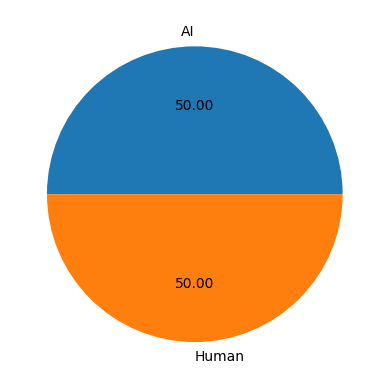

In [3]:
# Checking for dataset imbalance
ai,human=df.iloc[:,-1].value_counts()*1.0
plt.pie(x=[ai,human],labels=['AI','Human'],autopct="%.2f")
plt.show()

In [4]:
# Check for nulls in dataset
df.isnull().sum()

text     0
label    0
dtype: int64

In [5]:
# Replacing author names with binary labels
df['label']=[1 if author=='AI' else 0 for author in df['label']]
df.head()

,text,label
0,"Got take-out. Very friendly staff, reasonable ...",0
1,Love this bar! Fun crowd and the staff are all...,0
2,"After watching Whale Wars: Viking Shores, I ca...",0
3,Kelly really wanted the new iPhone. She begged...,0
4,Though this is the easiest way to secure a spo...,0


In [6]:
# Cleaning the texts
def text_cleaning(text):
    text=text.lower()
    text=re.sub(r'\n',' ',text)
    text=re.sub(r'\s+',' ',text)
    return text
df['text']=df['text'].apply(text_cleaning)
df.head()

,text,label
0,"got take-out. very friendly staff, reasonable ...",0
1,love this bar! fun crowd and the staff are all...,0
2,"after watching whale wars: viking shores, i ca...",0
3,kelly really wanted the new iphone. she begged...,0
4,though this is the easiest way to secure a spo...,0


In [7]:
# Check for duplicates in the dataset
df.duplicated(subset='text').sum()

np.int64(168)

In [8]:
# Dropping duplicates
df=df.drop_duplicates(subset='text')
df.duplicated(subset='text').sum()

np.int64(0)

In [9]:
# Checking total number of unique words in the dataset
all_words=Counter()
for text in df["text"]:
    all_words.update(text.split())
print(len(all_words))

925347


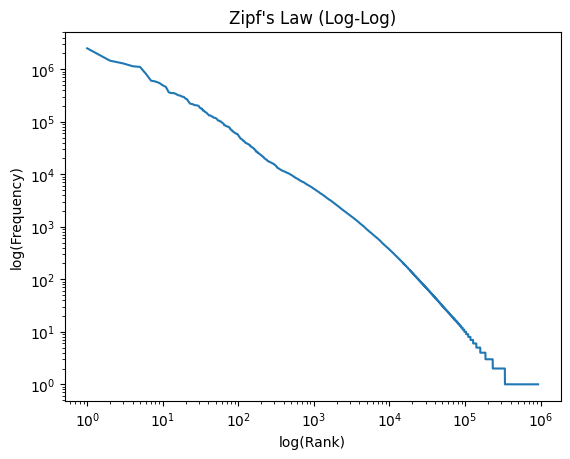

In [10]:
# Test for Zipf's Law
sorted_words=all_words.most_common()
ranks=np.arange(1,len(sorted_words)+1)
frequencies=np.array([freq for _,freq in sorted_words])
plt.figure()
plt.loglog(ranks,frequencies)
plt.xlabel("log(Rank)")
plt.ylabel("log(Frequency)")
plt.title("Zipf's Law (Log-Log)")
plt.show()

In [11]:
# Tail Test
rare_words=sum(1 for w,c in all_words.items() if c==1)
print(rare_words)

589308


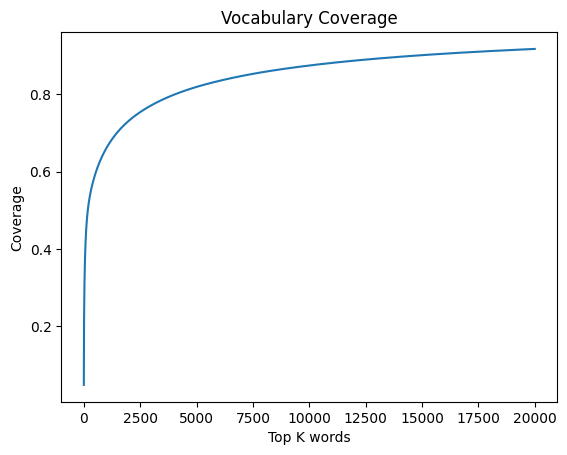

In [12]:
# Coverage Analysis
total_words=sum(frequencies)
cumulative=np.cumsum(frequencies)/total_words
plt.figure()
plt.plot(ranks[:20000],cumulative[:20000])
plt.xlabel("Top K words")
plt.ylabel("Coverage")
plt.title("Vocabulary Coverage")
plt.show()

In [13]:
# Splitting the dataset into train and text split
X_train,X_test,y_train,y_test=train_test_split(df['text'],df['label'],test_size=0.2,random_state=42,stratify=df['label'])
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((265651,), (265651,), (66413,), (66413,))

In [14]:
# Vectorising text data using CountVectorizer
count_vectorizer=CountVectorizer(max_features=20000,
                                 ngram_range=(1,2),
                                 min_df=2,
                                 max_df=0.9)
X_train_count=count_vectorizer.fit_transform(X_train)
X_test_count=count_vectorizer.transform(X_test)

In [15]:
# Vectorising text data using TFIDFVectorizer
tfidf_vectorizer=TfidfVectorizer(max_features=20000,
                                 ngram_range=(1,2),
                                 min_df=2,
                                 max_df=0.9)
X_train_tfidf=tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf=tfidf_vectorizer.transform(X_test)

              precision    recall  f1-score   support

           0       0.73      0.68      0.70     33194
           1       0.70      0.75      0.72     33219

    accuracy                           0.71     66413
   macro avg       0.71      0.71      0.71     66413
weighted avg       0.71      0.71      0.71     66413



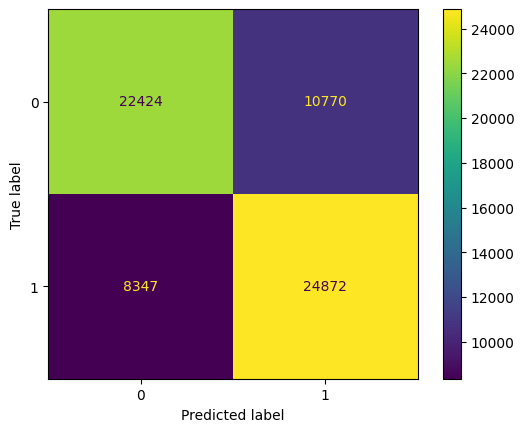

In [16]:
# Multinomial Naive Bayes with CountVectorizer
nb_model_count=MultinomialNB()
nb_model_count.fit(X_train_count,y_train)
y_pred_nb_count=nb_model_count.predict(X_test_count)
print(classification_report(y_test,y_pred_nb_count))
cm=confusion_matrix(y_test,y_pred_nb_count,labels=nb_model_count.classes_)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=nb_model_count.classes_)
disp.plot()
plt.show()

              precision    recall  f1-score   support

           0       0.76      0.68      0.71     33194
           1       0.71      0.79      0.74     33219

    accuracy                           0.73     66413
   macro avg       0.73      0.73      0.73     66413
weighted avg       0.73      0.73      0.73     66413



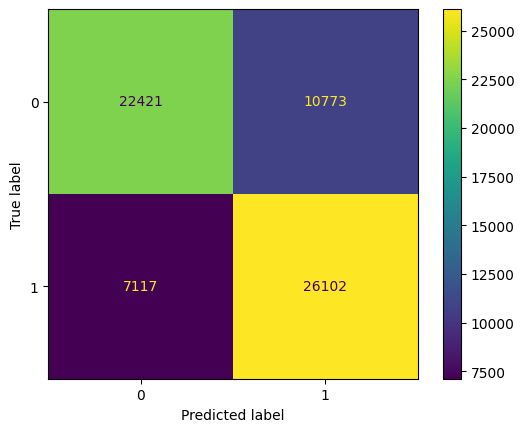

In [17]:
# Multinomial Naive Bayes with TfidfVectorizer
nb_model_tfidf=MultinomialNB()
nb_model_tfidf.fit(X_train_tfidf,y_train)
y_pred_nb_tfidf=nb_model_tfidf.predict(X_test_tfidf)
print(classification_report(y_test,y_pred_nb_tfidf))
cm=confusion_matrix(y_test,y_pred_nb_tfidf,labels=nb_model_tfidf.classes_)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=nb_model_tfidf.classes_)
disp.plot()
plt.show()

              precision    recall  f1-score   support

           0       0.82      0.82      0.82     33194
           1       0.82      0.82      0.82     33219

    accuracy                           0.82     66413
   macro avg       0.82      0.82      0.82     66413
weighted avg       0.82      0.82      0.82     66413



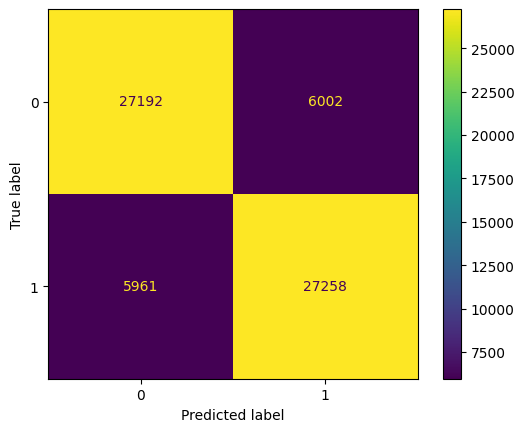

In [18]:
# Logistic Regression with CountVectorizer
lr_model_count=LogisticRegression(random_state=42)
lr_model_count.fit(X_train_count,y_train)
y_pred_lr_count=lr_model_count.predict(X_test_count)
print(classification_report(y_test,y_pred_lr_count))
cm=confusion_matrix(y_test,y_pred_lr_count,labels=lr_model_count.classes_)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=lr_model_count.classes_)
disp.plot()
plt.show()

              precision    recall  f1-score   support

           0       0.83      0.82      0.83     33194
           1       0.82      0.83      0.83     33219

    accuracy                           0.83     66413
   macro avg       0.83      0.83      0.83     66413
weighted avg       0.83      0.83      0.83     66413



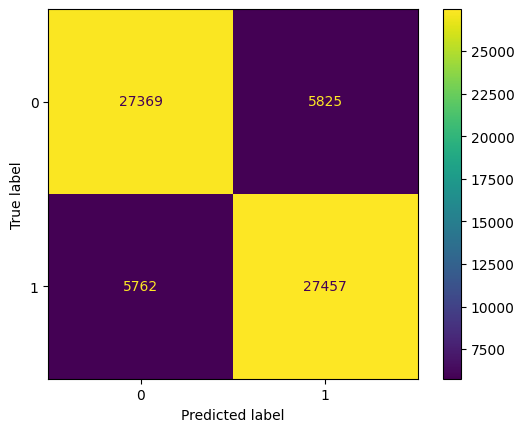

In [19]:
# Logistic Regression with TfidfVectorizer
lr_model_tfidf=LogisticRegression(random_state=42)
lr_model_tfidf.fit(X_train_tfidf,y_train)
y_pred_lr_tfidf=lr_model_tfidf.predict(X_test_tfidf)
print(classification_report(y_test,y_pred_lr_tfidf))
cm=confusion_matrix(y_test,y_pred_lr_tfidf,labels=lr_model_tfidf.classes_)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=lr_model_tfidf.classes_)
disp.plot()
plt.show()

In [20]:
# Saving best performing model
joblib.dump(tfidf_vectorizer,'tfidf_vectorizer.joblib')
joblib.dump(lr_model_tfidf,'logistic_regression_model.joblib') 

['logistic_regression_model.joblib']